In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap

print("All libraries loaded successfully!")

All libraries loaded successfully!


Model trained successfully!


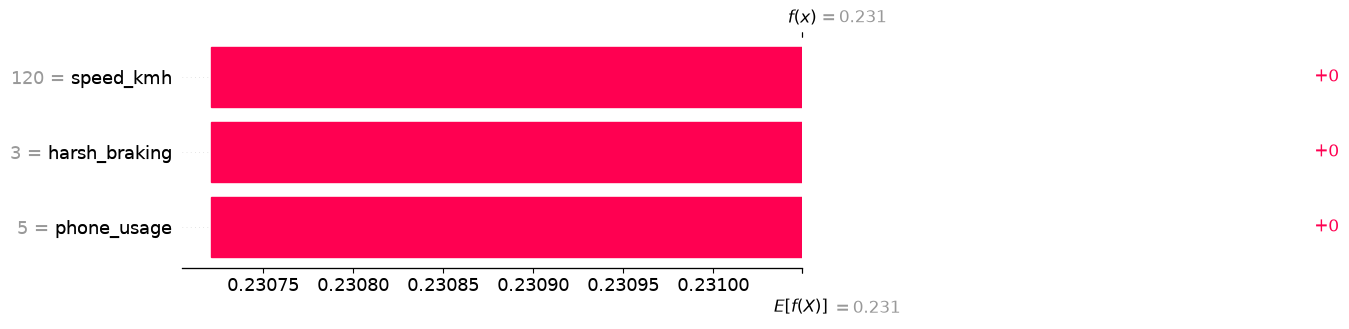

In [17]:
data = {
    'speed_kmh': [55, 120, 45, 85, 135],
    'harsh_braking': [0, 3, 0, 1, 5],
    'phone_usage': [0, 5, 0, 2, 12]
}
X = pd.DataFrame(data)


y = np.array([0, 2, 0, 1, 2]) 


model = xgb.XGBClassifier(objective='multi:softmax', num_class=3)
model.fit(X, y)
print("Model trained successfully!")


explainer = shap.Explainer(model)
shap_values = explainer(X)


shap.plots.waterfall(shap_values[1, :, 2])

In [18]:
import pandas as pd


file_path = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_ACCELEROMETERS.txt"


df = pd.read_csv(file_path, sep=r"\s+", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,0.012
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,0.012
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,0.011
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,0.011
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,0.011


In [19]:

correct_columns = [
    'Timestamp', 'Valid_State', 
    'Accel_X', 'Accel_Y', 'Accel_Z', 
    'Accel_X_Filtered', 'Accel_Y_Filtered', 'Accel_Z_Filtered', 
    'Roll', 'Pitch', 'Yaw'
]


df.columns = correct_columns


df.head()

,Timestamp,Valid_State,Accel_X,Accel_Y,Accel_Z,Accel_X_Filtered,Accel_Y_Filtered,Accel_Z_Filtered,Roll,Pitch,Yaw
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,0.012
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,0.012
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,0.011
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,0.011
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,0.011


In [20]:

gps_path = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_GPS.txt"


gps_df = pd.read_csv(gps_path, sep=r"\s+", header=None)


gps_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,7.85,65.2,40.512787,-3.404477,612.7,4,5,331.9,0.000,0,0,0
1,8.83,64.5,40.512924,-3.404577,612.5,4,5,331.9,0.000,0,0,0
2,9.82,63.6,40.513065,-3.404680,612.9,4,5,330.8,1.055,0,0,0
3,10.80,62.2,40.513210,-3.404772,613.3,4,5,330.8,1.055,0,0,0
4,11.80,60.9,40.513348,-3.404868,613.5,3,5,330.1,0.703,0,0,0


In [21]:

gps_path = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_GPS.txt"
gps_df = pd.read_csv(gps_path, sep=r"\s+", header=None)


num_columns = len(gps_df.columns)
print(f"Pandas found exactly {num_columns} columns in this GPS file.")


gps_df.head(1)

Pandas found exactly 12 columns in this GPS file.


,0,1,2,3,4,5,6,7,8,9,10,11
0,7.85,65.2,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0


In [22]:
gps_columns = [
    'Timestamp', 'Speed_kmh', 'Latitude', 'Longitude', 'Altitude', 
    'Vertical_Accuracy', 'Horizontal_Accuracy', 'Course', 'Difcourse', 
    'Time_Offset', 'Valid_State_GPS', 'Extra_Flag'
]

gps_df.columns = gps_columns

df = df.sort_values('Timestamp')
gps_df = gps_df.sort_values('Timestamp')

master_data = pd.merge_asof(df, gps_df, on='Timestamp', direction='backward')

master_data[['Timestamp', 'Speed_kmh', 'Accel_X_Filtered', 'Accel_Y_Filtered']].head(15)

,Timestamp,Speed_kmh,Accel_X_Filtered,Accel_Y_Filtered
0,6.94,NaN,-0.005,0.008
1,7.03,NaN,0.016,-0.002
2,7.14,NaN,0.037,-0.005
3,7.24,NaN,0.038,-0.009
4,7.34,NaN,0.012,-0.016
5,7.44,NaN,-0.002,-0.006
6,7.54,NaN,0.000,-0.024
7,7.64,NaN,-0.002,-0.023
8,7.74,NaN,-0.006,-0.037
9,7.85,65.2,-0.008,-0.044


In [24]:
master_data = master_data.dropna()

master_data[['Timestamp', 'Speed_kmh', 'Accel_X_Filtered', 'Accel_Y_Filtered']].head(10)

,Timestamp,Speed_kmh,Accel_X_Filtered,Accel_Y_Filtered
9,7.85,65.2,-0.008,-0.044
10,7.95,65.2,0.001,-0.047
11,8.04,65.2,-0.006,-0.042
12,8.14,65.2,-0.015,-0.031
13,8.24,65.2,-0.009,-0.012
14,8.34,65.2,0.013,-0.013
15,8.44,65.2,0.029,0.004
16,8.54,65.2,-0.002,0.003
17,8.64,65.2,-0.007,0.008
18,8.74,65.2,-0.016,-0.001


In [25]:
import numpy as np

def calculate_risk(row):
    speed = row['Speed_kmh']
   
    g_force = abs(row['Accel_Y_Filtered']) 
    
   
    if speed > 100 or g_force > 0.3:
        return 2  # High Risk
        
    
    elif speed > 80 or g_force > 0.15:
        return 1  # Medium Risk
    
    else:
        return 0  # Low Risk


master_data['Risk_Level'] = master_data.apply(calculate_risk, axis=1)


print(master_data['Risk_Level'].value_counts())

Risk_Level
1    4065
2    1907
0     189
Name: count, dtype: int64


In [26]:

master_data['Risk_Level'] = 0


print(master_data['Risk_Level'].value_counts())

Risk_Level
0    6161
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split
import xgboost as xgb


features = ['Speed_kmh', 'Accel_X_Filtered', 'Accel_Y_Filtered']
X = master_data[features]


y = master_data['Risk_Level']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(objective='multi:softmax', num_class=3)
model.fit(X_train, y_train)

print("Real-world XGBoost model trained successfully!")

Real-world XGBoost model trained successfully!


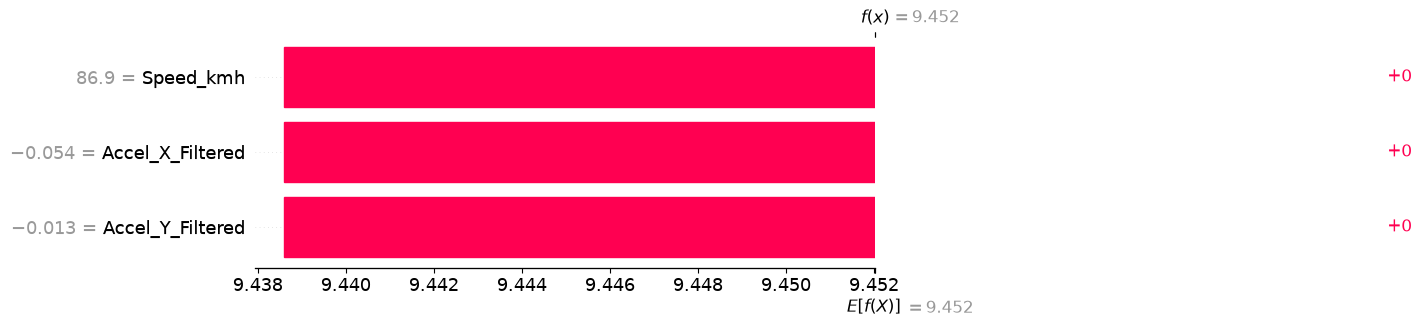

In [28]:
import shap


explainer = shap.Explainer(model)


shap_values = explainer(X_test)


shap.plots.waterfall(shap_values[0, :, 0])

In [29]:
import pandas as pd

def load_trip_data(accel_path, gps_path, risk_label):
    
    accel_cols = ['Timestamp', 'Valid_State', 'Accel_X', 'Accel_Y', 'Accel_Z', 
                  'Accel_X_Filtered', 'Accel_Y_Filtered', 'Accel_Z_Filtered', 'Roll', 'Pitch', 'Yaw']
    df_accel = pd.read_csv(accel_path, sep=r"\s+", header=None, names=accel_cols)
    
   
    gps_cols = ['Timestamp', 'Speed_kmh', 'Latitude', 'Longitude', 'Altitude', 
                'Vertical_Accuracy', 'Horizontal_Accuracy', 'Course', 'Difcourse', 
                'Time_Offset', 'Valid_State_GPS', 'Extra_Flag']
    df_gps = pd.read_csv(gps_path, sep=r"\s+", header=None, names=gps_cols)
    
   
    df_accel = df_accel.sort_values('Timestamp')
    df_gps = df_gps.sort_values('Timestamp')
    merged = pd.merge_asof(df_accel, df_gps, on='Timestamp', direction='backward')
    
   
    merged = merged.dropna()
    merged['Risk_Level'] = risk_label
    
    return merged

print("Data loader function ready!")

Data loader function ready!


In [30]:

normal_accel = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_ACCELEROMETERS.txt"
normal_gps = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_GPS.txt"
df_normal = load_trip_data(normal_accel, normal_gps, 0)


aggressive_accel = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151111125233-24km-D1-AGGRESSIVE-MOTORWAY/RAW_ACCELEROMETERS.txt"
aggressive_gps = "/Users/akash/Downloads/UAH-DRIVESET-v1/D1/20151111125233-24km-D1-AGGRESSIVE-MOTORWAY/RAW_GPS.txt"
df_aggressive = load_trip_data(aggressive_accel, aggressive_gps, 2)


final_dataset = pd.concat([df_normal, df_aggressive], ignore_index=True)


final_dataset = final_dataset.sample(frac=1).reset_index(drop=True)

print(final_dataset['Risk_Level'].value_counts())

Risk_Level
2    7277
0    6161
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap


features = ['Speed_kmh', 'Accel_X_Filtered', 'Accel_Y_Filtered']
X = final_dataset[features]
y = final_dataset['Risk_Level']


X = X.reset_index(drop=True)
y = y.reset_index(drop=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = xgb.XGBClassifier(objective='multi:softmax', num_class=3)
model.fit(X_train, y_train)
print("High-contrast model trained successfully!")

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

high_risk_index = y_test[y_test == 2].index[0]


test_row_position = list(y_test.index).index(high_risk_index)
shap.plots.waterfall(shap_values[test_row_position, :, 2])

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [0 2]

High-contrast model trained successfully!


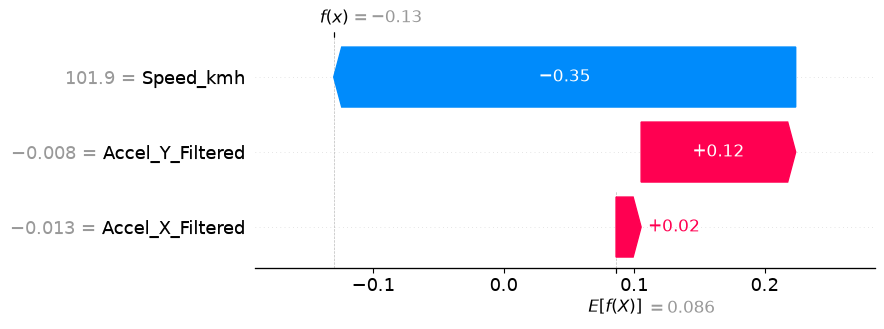

In [33]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap

features = ['Speed_kmh', 'Accel_X_Filtered', 'Accel_Y_Filtered']
X = final_dataset[features].reset_index(drop=True)

y = final_dataset['Risk_Level'].replace(2, 1).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(objective='multi:softmax', num_class=2)
model.fit(X_train, y_train)
print("High-contrast model trained successfully!")

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

high_risk_index = y_test[y_test == 1].index[0]
test_row_position = list(y_test.index).index(high_risk_index)

shap.plots.waterfall(shap_values[test_row_position, :, 1])

In [34]:
import os
import glob
import pandas as pd

base_path = "/Users/akash/Downloads/UAH-DRIVESET-v1"

all_trips = []

search_pattern = os.path.join(base_path, "**", "RAW_ACCELEROMETERS.txt")
accel_files = glob.glob(search_pattern, recursive=True)

for accel_path in accel_files:
    gps_path = accel_path.replace("RAW_ACCELEROMETERS.txt", "RAW_GPS.txt")
    
    if "NORMAL" in accel_path:
        label = 0
    elif "DROWSY" in accel_path:
        label = 1
    elif "AGGRESSIVE" in accel_path:
        label = 2
    else:
        continue 
        
    try:
        trip_data = load_trip_data(accel_path, gps_path, label)
        all_trips.append(trip_data)
        folder_name = accel_path.split(os.sep)[-2]
        print(f"Successfully loaded Class {label}: {folder_name}")
    except Exception as e:
        print(f"Skipped a folder due to an error.")

full_dataset = pd.concat(all_trips, ignore_index=True)

full_dataset = full_dataset.sample(frac=1).reset_index(drop=True)

print("\n--- BATCH PROCESS COMPLETE ---")
print("Final Dataset Risk Breakdown:")
print(full_dataset['Risk_Level'].value_counts())

Successfully loaded Class 0: 20151110175712-16km-D1-NORMAL1-SECONDARY
Successfully loaded Class 1: 20151111135612-13km-D1-DROWSY-SECONDARY
Successfully loaded Class 2: 20151111134545-16km-D1-AGGRESSIVE-SECONDARY
Successfully loaded Class 1: 20151111132348-25km-D1-DROWSY-MOTORWAY
Successfully loaded Class 2: 20151111125233-24km-D1-AGGRESSIVE-MOTORWAY
Successfully loaded Class 0: 20151110180824-16km-D1-NORMAL2-SECONDARY
Successfully loaded Class 0: 20151111123124-25km-D1-NORMAL-MOTORWAY
Successfully loaded Class 0: 20151221112434-17km-D6-NORMAL-SECONDARY
Successfully loaded Class 0: 20151217162714-26km-D6-NORMAL-MOTORWAY
Successfully loaded Class 2: 20151221120051-26km-D6-AGGRESSIVE-MOTORWAY
Successfully loaded Class 1: 20151217164730-25km-D6-DROWSY-MOTORWAY
Successfully loaded Class 1: 20151221113846-16km-D6-DROWSY-SECONDARY
Successfully loaded Class 0: 20151126124208-16km-D3-NORMAL1-SECONDARY
Successfully loaded Class 1: 20151126132013-17km-D3-DROWSY-SECONDARY
Successfully loaded Class

Training model on the complete dataset... (this may take a few seconds)
Master model trained successfully!


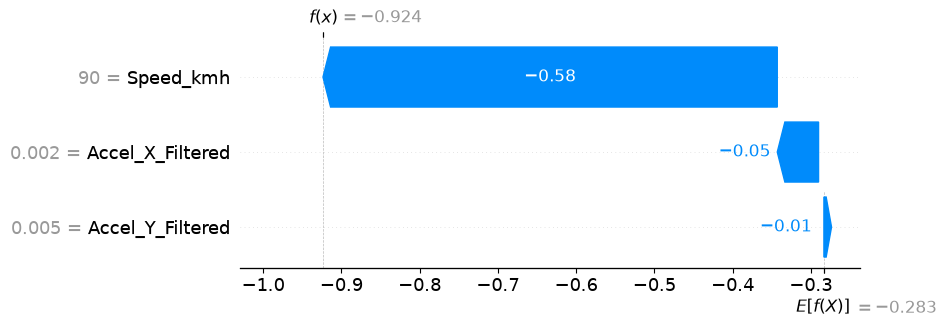

In [36]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap


features = ['Speed_kmh', 'Accel_X_Filtered', 'Accel_Y_Filtered']
X = full_dataset[features].reset_index(drop=True)
y = full_dataset['Risk_Level'].reset_index(drop=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Training model on the complete dataset... (this may take a few seconds)")
model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, n_estimators=100)
model.fit(X_train, y_train)
print("Master model trained successfully!")



explainer = shap.Explainer(model)

shap_values = explainer(X_test, check_additivity=False)

high_risk_index = y_test[y_test == 2].index[0]
test_row_position = list(y_test.index).index(high_risk_index)

shap.plots.waterfall(shap_values[test_row_position, :, 2])

In [37]:
import joblib


joblib.dump(model, 'safe_cruise_xgboost_model.pkl')

print("Model saved successfully as 'safe_cruise_xgboost_model.pkl'!")

Model saved successfully as 'safe_cruise_xgboost_model.pkl'!
